# Optimizing Marker Expression for Late MgkPro.

## Prepare Notebook.

### Autoreload Libraries.

In [1]:
%reload_ext autoreload
%autoreload 2

### Import the Libraries.

In [2]:
from functools import partial
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch


import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import torch

import labcompass
import scopt

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")

from experiment_utils import get_forward_model, generate_with_condition, generated_density_knn, get_adata_from_idx
from data_utils import (
    standardize_array_and_write_to_adata, get_condition_data_from_file,
    get_protocol_tranformations, get_target_adata_marker_opt
)
from inverse_utils import (
    map_df, l2_loss, l1_loss, hinge_loss, cauchy_loss, loss_fn_factory_marker_opt,
    linear_scheduler_with_warmup, constraint_fn_factory, replace_silu_with_safe_silu
)
from lambda_schedulers import ReciprocalDecayScheduler
from plot_utils import plot_all_markers_overlay


## Load Stuff.

### Load Configurations.

In [3]:
with hydra.initialize(
    config_path="../../config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "annotation=bloodplus",
            "sampling.N=10",
            "sampling.num_time_steps=20",
            "forward_model.num_time_steps=20",
            "constraints=default_all_cols"
        ]
    )

/tmp/ipykernel_3688989/377118890.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


### Load Prior Model.

In [4]:
# initialize prior models
prior_cfm = labcompass.models.FlowMatchingWithScore.load(
    config.paths.prior_flow_path
)
prior_fm = labcompass.models.FlowMap.load(
    config.paths.prior_flow_map_path
)
prior_cfm.velocity_field.eval()
prior_fm.flow_map.eval()

# show modules
print(prior_cfm.velocity_field)
print(prior_fm.flow_map)

NeuralVelocityFieldWithScore(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=16, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=8, bias=True)
          (1): Identity()
        )
      )
    )
    (resnet_blocks): ModuleList(
      (0-2): 3 x ResnetBlock(
        (net1): Sequential(
          (0): SiLU()
          (1): Linear(in_features=16, out_features=16, bias=True)
        )
        (cond_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=8, out_fe

### Load Forward Model.

In [5]:
forward_model, (
    phi_model,
    target_prediction_model
) = get_forward_model(config)
forward_model.target_prediction_model.resc_model["model"].eval()
forward_model.forward_model.velocity_field.eval()
print(forward_model.target_prediction_model.resc_model["model"])
print(forward_model.forward_model.velocity_field)

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=256, out_features=32, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=32, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)


### Patch Model for AD.

In [6]:
velocity_field_net = prior_cfm.velocity_field
flow_map_net = prior_fm.flow_map

replace_silu_with_safe_silu(velocity_field_net)
replace_silu_with_safe_silu(flow_map_net)


### Load Reference Media Concentrations.

In [7]:
condition_metadata_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/table_metadata_theis_unmix8.xlsx" 
protocol_data, condition_adata = get_condition_data_from_file(
    phi_model.data_manager,
    condition_metadata_path,
    config.annotation.protocol_columns,
    config.annotation.log1p_exp_cols,
    config.annotation.log21p_exp_cols,
    config.annotation.protocol_obs_key_added,
    config.annotation.protocol_sep,
    config.annotation.one_hot_uns_key_added,
    config.annotation.protocol_obsm_key,
)
condition_adata

/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


{'gm-csf_[ng_ml]': <ufunc 'log1p'>, 'tpo_[ng_ml]': <ufunc 'log1p'>, 'sr1_[nm]': <ufunc 'log1p'>, 'um171_[nm]': <ufunc 'log1p'>, 'um729_[µm]': <ufunc 'log1p'>, 'scf_[ng_ml]': <ufunc 'log1p'>, 'butyzamide_[nm]': <ufunc 'log1p'>, 'retinoic_acid_[µm]': <ufunc 'log1p'>, 'ldl_[ng_ml]': <ufunc 'log1p'>, 'il3_[ng_ml]': <ufunc 'log1p'>, 'o2_[%]': <ufunc 'log1p'>, 'days_of_culture': <ufunc 'log1p'>}


100%|██████████| 12/12 [00:00<00:00, 125.63it/s]


AnnData object with n_obs × n_vars = 6 × 2
    obs: 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture'
    obsm: 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture', 'condition_concat'

### Read Original Annotation File.

In [8]:
experiment_id = "LPHO012"
additional_df_cols = ["experiment_number"]

condition_df = pd.read_excel(condition_metadata_path)
condition_df.columns = [col.replace("/", "_") for col in condition_df.columns]

all_df_cols = additional_df_cols + config.annotation.protocol_columns
lph_df = condition_df.loc[condition_df.experiment_id == experiment_id, all_df_cols]
lph_df

,experiment_number,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
262,205,10,2.5,750,560.0,0.0,10,0,0,0,0.0,20,14
263,206,10,2.5,375,560.0,0.0,10,0,0,0,0.0,20,14
264,207,10,2.5,75,560.0,0.0,10,0,0,0,0.0,20,14
265,208,10,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14
266,209,0,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14
267,210,0,0.0,0,70.0,0.0,0,100,0,0,0.0,20,14


## Prepare Data.

### Concatenate Full Data.

In [9]:
# data for cellular response prediction model (full)
train_adata_phi = phi_model.train_data.adata
val_adata_phi = next(iter(phi_model.validation_data.values())).adata
adata_phi = sc.concat((train_adata_phi, val_adata_phi), uns_merge="same")
print(f"Full data shape: {adata_phi.shape}")

Full data shape: (52085765, 20)


### Concatenate Annotated Subset.

In [10]:
# data for classifier model (subset)
train_adata_g = target_prediction_model.train_data.adata
val_adata_g = target_prediction_model.validation_data.adata
adata_g = sc.concat((train_adata_g, val_adata_g), uns_merge="same")
print(f"Subset data shape: {adata_g.shape}")

Subset data shape: (471836, 20)


### Fit Label Encoder.

In [11]:
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()

## Get Target Values.

### Prepare Target Adatas.

In [12]:
# define target markers
target_marker_names = [
    # "CD34",
    "CD41a",
    # "CD56",
    # "EPCR"
]
target_morph_feat_names = [
    # "SSC-A :: SSC - Area",
    # "FSC-A :: FSC - Area",
]

# define aggregation functions
agg_fn_dict = {
    "mean": np.mean,
    "median": np.median,
    "min": np.min,
    "max": np.max,
    "pop": lambda x: x,
}

# define filter configurations
filter_dict = {
    # "experiment_number": 210,
    # "cell_type": "late_MgkPro",
}
target_quantile = 99.5

target_adatas_dict = {}
for agg_id, agg_fn in agg_fn_dict.items():
    # prepare keyword arguments for aggregation
    agg_fn_kwargs = {"axis": 0, "keepdims": True} if agg_id != "pop" else {}

    target_adata, query_adata = get_target_adata_marker_opt(
        train_adata_phi,
        adata_g,
        agg_fn,
        target_marker_names,
        target_morph_feat_names,
        config.annotation.scatter_columns,
        filter_dict,
        target_quantile,
        agg_fn_kwargs=agg_fn_kwargs,
    )
    target_adatas_dict[agg_id] = target_adata
target_feats_mask = query_adata.uns["target_feats_mask"]
print(target_adatas_dict.keys())

Number query cells before aggregation: 2360
Number query cells after aggregation: 1
Number query cells before aggregation: 2360
Number query cells after aggregation: 1
Number query cells before aggregation: 2360
Number query cells after aggregation: 1
Number query cells before aggregation: 2360
Number query cells after aggregation: 1
Number query cells before aggregation: 2360
Number query cells after aggregation: 2360
dict_keys(['mean', 'median', 'min', 'max', 'pop'])


### Plot Retained Cells.

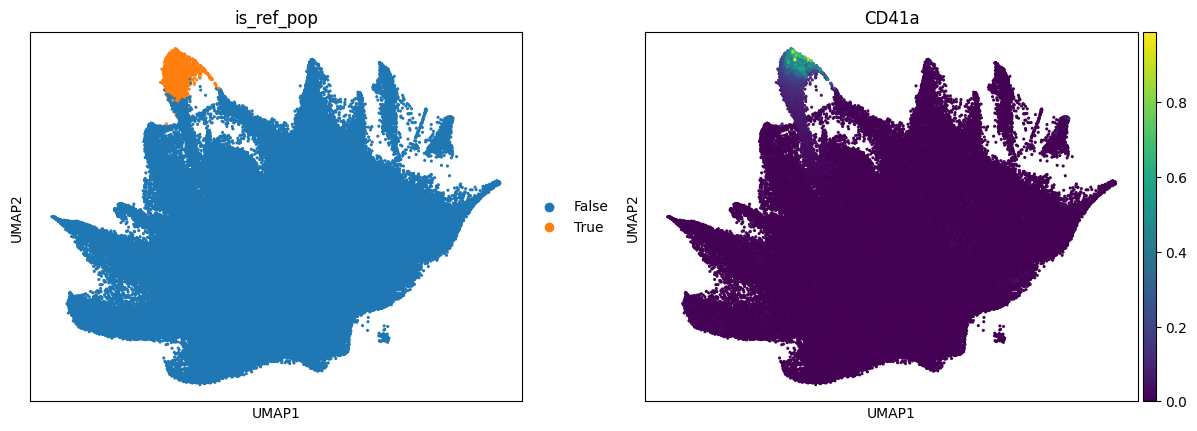

In [13]:
ref_main_idx = adata_g.obs.index.map(lambda e: e in query_adata.obs.index)
adata_g.obs["is_ref_pop"] = ref_main_idx
target_feat_names = target_marker_names + target_morph_feat_names
sc.pl.embedding(adata_g, "umap", color=["is_ref_pop"] + target_feat_names, s=20)

### Visualizing Resulting Targets After Transformation.

In [14]:
cell_state_rep_orig = "X_channel+X_scatter"
cell_state_rep_std = "X_channel_standardized+X_scatter_standardized"
all_feat_names = adata_g.var_names.to_list() + config.annotation.scatter_columns
for target_type, target_adata in target_adatas_dict.items():
    print(f"="*80)
    print(f"Target Type {target_type}")
    for idx, var_name in enumerate(all_feat_names):
        if var_name in target_feat_names:
            val_orig = target_adata.obsm[cell_state_rep_orig][:, idx].mean(0)
            val_std = target_adata.obsm[cell_state_rep_std][:, idx].mean(0)
            print(f"TARGET {var_name} -> Before {val_orig.item()}, Rescaled: {val_std.item()}")

Target Type mean
TARGET CD41a -> Before 1.5057981240294747, Rescaled: 10.709153534198322
Target Type median
TARGET CD41a -> Before 1.5207343101501465, Rescaled: 10.816667365655507
Target Type min
TARGET CD41a -> Before 0.9828155636787415, Rescaled: 6.944614287410553
Target Type max
TARGET CD41a -> Before 2.255382537841797, Rescaled: 16.104820920668057
Target Type pop
TARGET CD41a -> Before 1.5057981240294747, Rescaled: 10.709153534198323


### Prepare Tensor Representations for Target States.

In [15]:
cell_state_rep = "X_channel_standardized+X_scatter_standardized"
device = "cuda"
dtype = torch.float32
xopt_dict_torch = {
    target_type: torch.from_numpy(target_adata.obsm[cell_state_rep]).\
        to(dtype).to(device)
    for target_type, target_adata in target_adatas_dict.items()
}
for target_type, xopt_torch in xopt_dict_torch.items():
    print(f"{target_type} -> {xopt_torch.shape}, {xopt_torch[:, target_feats_mask]}")


mean -> torch.Size([1, 26]), tensor([[10.7092]], device='cuda:0')
median -> torch.Size([1, 26]), tensor([[10.8167]], device='cuda:0')
min -> torch.Size([1, 26]), tensor([[6.9446]], device='cuda:0')
max -> torch.Size([1, 26]), tensor([[16.1048]], device='cuda:0')
pop -> torch.Size([2360, 26]), tensor([[11.5524],
        [11.6760],
        [13.8389],
        ...,
        [ 7.0092],
        [ 8.8675],
        [ 8.7840]], device='cuda:0')


## Run Optimization (Loss Guidance).

### Prepare Losses.

In [16]:
loss_registry = {
    "l2": l2_loss,
    "l1": l1_loss,
    "hinge": hinge_loss,
    "cauchy": cauchy_loss,
}
loss_fn_dict = {}
non_linearity = torch.nn.Identity()
for target_type in ["max", "min", "mean", "median"]:
    for loss_type, loss_fn in loss_registry.items():
        for agg_type in ["pop", "cell"]:
            xstar = xopt_dict_torch[target_type]          # (1, D)
            loss_fn_comp, noise = loss_fn_factory_marker_opt(
                config, loss_fn, xstar, non_linearity, phi_model,
                target_feats_mask, agg_type
            )
            loss_fn_dict[f"{target_type}_{loss_type}_{agg_type}"] = {"loss_fn": loss_fn_comp, "noise": noise}
print(loss_fn_dict.keys())

dict_keys(['max_l2_pop', 'max_l2_cell', 'max_l1_pop', 'max_l1_cell', 'max_hinge_pop', 'max_hinge_cell', 'max_cauchy_pop', 'max_cauchy_cell', 'min_l2_pop', 'min_l2_cell', 'min_l1_pop', 'min_l1_cell', 'min_hinge_pop', 'min_hinge_cell', 'min_cauchy_pop', 'min_cauchy_cell', 'mean_l2_pop', 'mean_l2_cell', 'mean_l1_pop', 'mean_l1_cell', 'mean_hinge_pop', 'mean_hinge_cell', 'mean_cauchy_pop', 'mean_cauchy_cell', 'median_l2_pop', 'median_l2_cell', 'median_l1_pop', 'median_l1_cell', 'median_hinge_pop', 'median_hinge_cell', 'median_cauchy_pop', 'median_cauchy_cell'])


### Sample from Inverse Model.

In [36]:
# parameters for sampler
estimator = "hutch-rademacher"
gamma = 1.0
horizon = .5
use_flow_map_score_estimator = False
use_langevin = False

# parameter for sde integration
num_time_steps = 500
solver_kwargs = {"method": "euler", "atol": 5e-5, "rtol": 5e-5}

# get loss function
agg = "min"
loss_type = "cell" # "cell" "pop"
loss_fn_id = "l2"
loss_name = f"{agg}_{loss_fn_id}_{loss_type}"
adata_ref = target_adatas_dict[agg]
loss_fn_comp = loss_fn_dict[loss_name]["loss_fn"]

# initialize time rescaling scheduler and inverse model
time_warping = scopt.schedulers.LinearWarping(horizon=horizon)
wgf = scopt.methods.ULAGuidedFlow(
    loss_fn_comp,
    prior_cfm,
    flow_map=prior_fm,
    scheduler=time_warping,
    gamma=gamma,
    estimator=estimator,
    use_flow_map_score_estimator=use_flow_map_score_estimator,
    use_langevin=use_langevin,
)

# sample from model
traj = wgf.sample(
    config.sampling.N,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
).detach().cpu().numpy()
torch.cuda.empty_cache()
print(f"{traj.shape=}")

traj.shape=(500, 10, 12)


### Recompute Loss Along Trajectory.

In [37]:
# Compute loss history by mapping each intermediate state to t=1
T = traj.shape[0] - 1
times = np.linspace(0.0, 1.0, T+1)
loss_history = []
for t_idx, t in enumerate(times):
    x_t = torch.from_numpy(traj[t_idx]).to(prior_cfm.device)
    t_tensor = torch.full((x_t.shape[0],), t, device=prior_cfm.device)
    t_target = torch.ones_like(t_tensor)
    with torch.no_grad():
        x_1 = prior_fm.flow_map(t_tensor, t_target, x_t)
    loss_vals = loss_fn_comp(x_1).detach().cpu()
    loss_history.append(loss_vals)
loss_history = torch.stack(loss_history, dim=0)
print(f"{traj.shape=}, {loss_history.shape=}")

traj.shape=(500, 10, 12), loss_history.shape=torch.Size([500, 10])


### Visualize loss history.

/tmp/ipykernel_3688989/2542757849.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  loss_arr = np.array(loss_history.cpu())   # shape (T+1, N)


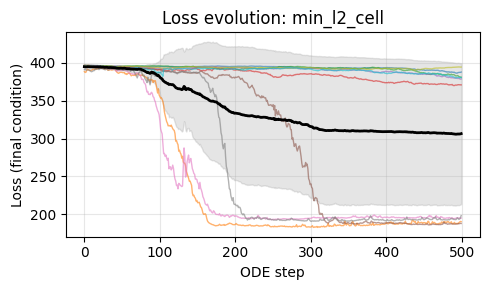

In [38]:
# loss_history is a list of length (num_time_steps+1), each element a numpy array (N,)
loss_arr = np.array(loss_history.cpu())   # shape (T+1, N)
T = loss_arr.shape[0] - 1
steps = np.arange(T+1)

# Plot individual samples (first up to 10)
plt.figure(figsize=(5, 3))
N_samples = loss_arr.shape[1]
for i in range(min(N_samples, 10)):
    plt.plot(steps, loss_arr[:, i], alpha=0.6, linewidth=1, label=f'Sample {i+1}')

# Add mean ± std
mean_loss = loss_arr.mean(axis=1)
std_loss = loss_arr.std(axis=1)
plt.plot(steps, mean_loss, 'k-', linewidth=2, label='Mean')
plt.fill_between(steps, mean_loss - std_loss, mean_loss + std_loss, 
                    alpha=0.2, color='gray', label='±1 std')

plt.xlabel('ODE step')
plt.ylabel('Loss (final condition)')
plt.title(f'Loss evolution: {loss_name}')
# plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualize Generated Samples.

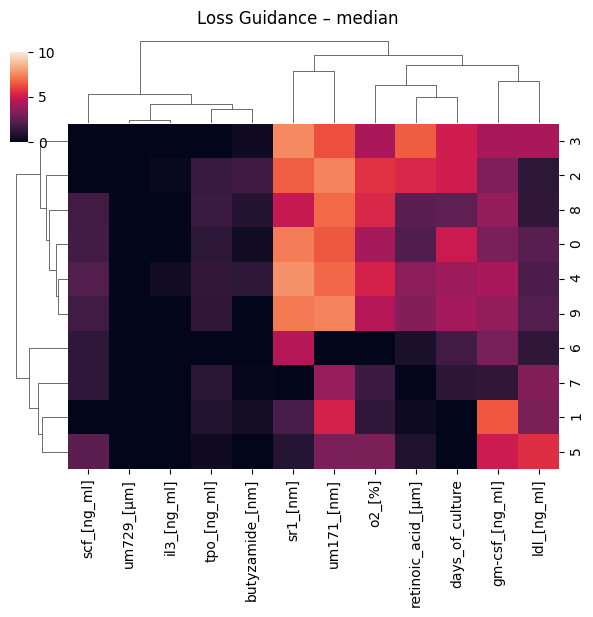

In [39]:
# Clip negative values to 0 (optional)
samples = traj[-1]
samples = np.maximum(samples, 0.0)

# Create clustermap with original values
g = sns.clustermap(
    samples,
    xticklabels=config.annotation.protocol_columns,
    figsize=(6, 6),
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    dendrogram_ratio=(0.1, 0.2),
    vmin=0.0,
    vmax=10.0,
    
)
g.fig.suptitle(f"Loss Guidance – {target_type}", y=1.02)
# Add title
plt.show()


### Tranform Samples Back to their Original Scale.

In [40]:
# get transformations
protocol_transf = get_protocol_tranformations(
    config.annotation.protocol_columns,
    log1p_exp_cols=config.annotation.log1p_exp_cols,
    log21p_exp_cols=config.annotation.log21p_exp_cols,
    inverse=True
)


samples = np.maximum(samples, 0)
raw_opt_df = pd.DataFrame(samples, columns=config.annotation.protocol_columns)
opt_df = map_df(raw_opt_df, protocol_transf)
print("="*80)
print(config.constraints.ubound_dict)
opt_df

{'gm-csf_[ng_ml]': 10.0, 'tpo_[ng_ml]': 2.5, 'um171_[nm]': 1120.0, 'um729_[µm]': 1120.0, 'sr1_[nm]': 750.0, 'scf_[ng_ml]': 50.0, 'butyzamide_[nm]': 100.0, 'retinoic_acid_[µm]': 25.0, 'ldl_[ng_ml]': 50.0, 'il3_[ng_ml]': 20.0, 'o2_[%]': 20.0, 'days_of_culture': 18.0}


,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
0,21.709778,2.248174,1443.578369,662.321716,0.0,5.020220,0.585682,7.113513,9.264800,0.000000,59.827168,146.166107
1,642.517334,1.518720,5.827625,188.223068,0.0,0.000000,0.647503,0.409858,22.483665,0.000000,2.387215,0.000000
2,23.651913,3.376199,752.538574,1662.712280,0.0,0.000000,4.229943,227.027618,2.250466,0.229866,290.657471,163.211975
3,61.972660,0.000000,1943.536987,559.764954,0.0,0.000000,0.494205,708.838989,64.612259,0.000000,66.688881,165.018967
4,63.100574,2.830746,2355.665039,905.590576,0.0,7.396422,2.263689,33.237846,6.565321,0.538077,192.425156,47.622662
5,151.975128,0.492638,1.757715,21.669531,0.0,9.848125,0.000000,1.410323,275.511780,0.000000,21.915794,0.000000
6,19.277103,0.000000,83.205719,0.000000,0.0,2.408805,0.000000,1.002246,2.542749,0.000000,0.000000,4.751657
7,2.626455,2.072836,0.000000,42.737637,0.0,2.366743,0.139062,0.112982,27.233013,0.000000,3.984240,2.156124
8,40.533607,3.646101,131.588699,958.585876,0.0,4.587103,1.622029,9.527248,2.568160,0.000000,222.253845,11.081480
9,39.317360,2.622877,1353.077881,1656.437866,0.0,4.441813,0.025606,26.784674,7.324832,0.000000,88.278931,58.944298


### Sakurai Medium.

In [ ]:
lph_df[lph_df.experiment_number == 210][config.annotation.protocol_columns]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
267,0,0.0,0,70.0,0.0,0,100,0,0,0.0,20,14


: 

### Query Forward Model.

Target: median
X_true.shape=(471836, 20), X_generated.shape=(10, 350, 20)
Sample index 0
gm-csf_[ng_ml]          21.709778
tpo_[ng_ml]              2.248174
sr1_[nm]              1443.578369
um171_[nm]             662.321716
um729_[µm]               0.000000
scf_[ng_ml]              5.020220
butyzamide_[nm]          0.585682
retinoic_acid_[µm]       7.113513
ldl_[ng_ml]              9.264800
il3_[ng_ml]              0.000000
o2_[%]                  59.827168
days_of_culture        146.166107
Name: 0, dtype: float32


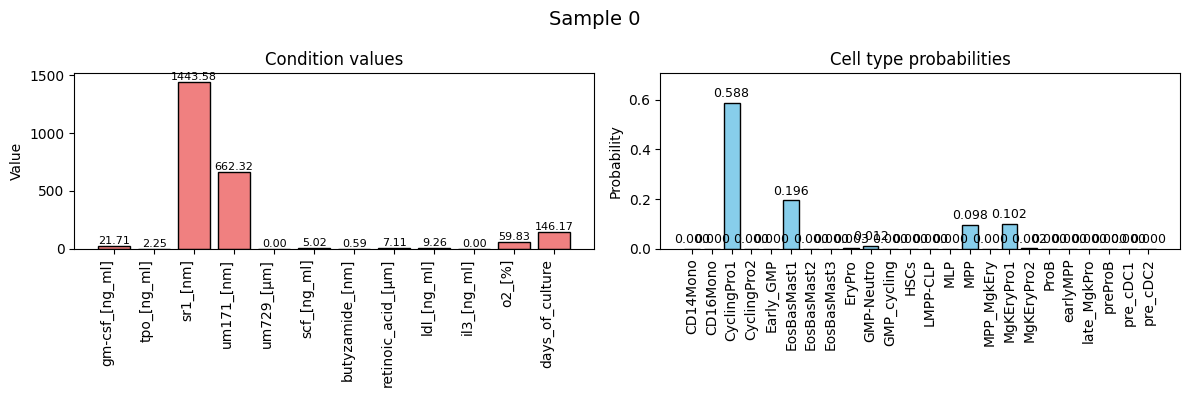

In [ ]:
# settings for generation
plot_umap_density = True
num_time_steps = 100
solver_kwargs = {"method": "euler", "atol": 5e-5, "rtol": 5e-5}
min_loss_idx = 5
density_type = "channel" # "scatter", "channel"

# Loop over all target types and EGF settings
print("="*80)
print(f"Target: {target_type}")
# query forward model with condition
opt_samples = np.maximum(samples, 0)
fwd_out = generate_with_condition(
    opt_samples,
    forward_model,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=None,
    noise=noise,
    logger=None,
    n_scatter_feats=6,
)

# prepare cell type proportions
mean_ct_probs = fwd_out["ct_probs"].mean(0)
cell_types = ct_le.classes_

# configure density type
def get_density_input(
    adata_g,
    fwd_out,
    density_type,
):
    if density_type == "joint":
        X_true = adata_g.obsm["X_channel_standardized+X_scatter_standardized"]
        X_generated = fwd_out["X"]
    elif density_type == "scatter":
        X_true = adata_g.obsm["X_scatter_standardized"]
        X_generated = fwd_out["X_scatter"]
    elif density_type == "channel":
        X_true = adata_g.obsm["X_channel_standardized"]
        X_generated = fwd_out["X_channel"]
    else:
        raise ValueError(f"Unsupported density type {density_type}")
    return X_true, X_generated

X_true, X_generated = get_density_input(
    adata_g,
    fwd_out,
    density_type,
)
print(f"{X_true.shape=}, {X_generated.shape=}")

# Plot each generated sample
if plot_umap_density:
    for idx in range(fwd_out["X"].shape[0]):
        print(f"Sample index {idx}")
        # Access the transformed condition values (already in original scale)
        print(opt_df.iloc[idx])

        cond_row = opt_df.iloc[idx]
        ct_probs_i = mean_ct_probs[idx]   # per-sample probabilities, not overall mean

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Left: condition values
        bars1 = ax1.bar(range(len(cond_row)), cond_row.values,
                        color='lightcoral', edgecolor='black')
        for bar, val in zip(bars1, cond_row.values):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
        ax1.set_xticks(range(len(cond_row)))
        ax1.set_xticklabels(cond_row.index, rotation=90, ha='right')
        ax1.set_title('Condition values')
        ax1.set_ylabel('Value')

        # Right: cell type probabilities
        bars2 = ax2.bar(cell_types, ct_probs_i, color='skyblue', edgecolor='black')
        for bar, val in zip(bars2, ct_probs_i):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
        ax2.set_title('Cell type probabilities')
        ax2.set_ylabel('Probability')
        ax2.set_ylim(0, max(ct_probs_i) * 1.2)
        ax2.tick_params(axis='x', rotation=90)

        fig.suptitle(f'Sample {idx}', fontsize=14)
        plt.tight_layout()
        plt.show()

        density = generated_density_knn(
            X_true,
            X_generated[idx],
            k=20,
            bandwidth=None
        )
        adata_g.obs["density"] = density
        sc.pl.embedding(
            adata_g, "umap",
            color=["density", "cell_type", "is_ref_pop"] + target_feat_names,
            s=20, legend_loc="on data"
        )


### Visualize.

Target: min


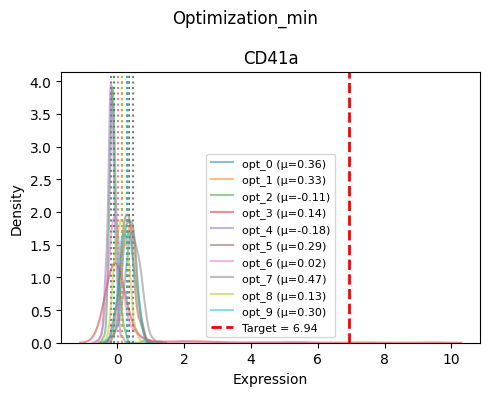

In [ ]:
# ========== Setup ==========
save_plots = False
plot_dir = "./optimization_plots"
if save_plots:
    os.makedirs(plot_dir, exist_ok=True)

# Indices of target markers (these variables must exist: all_feat_names, target_feat_names)
marker_indices = [all_feat_names.index(m) for m in target_feat_names]

# Reference population matrix (for population targets)
ref_markers = target_adata[:, target_feat_names].X
if hasattr(ref_markers, 'toarray'):
    ref_markers = ref_markers.toarray()

# Simulation parameters (adjust if needed)
num_time_steps = 100
solver_kwargs = {"method": "euler", "atol": 5e-5, "rtol": 5e-5}

# ========== For a single target_type ==========
print("="*80)
print(f"Target: {agg}")

# Ensure opt_samples is non‑negative (shape: N x D_protocol)
opt_samples = traj[-1]
opt_samples = np.maximum(opt_samples, 0)

# Collect marker expressions from forward simulation
# fwd_out must be defined (e.g., output of generate_with_condition)
gen_markers_list = []
for idx in range(fwd_out["X"].shape[0]):
    X_gen = fwd_out["X"][idx]                     # (n_cells, n_features)
    gen_markers = X_gen[:, marker_indices]        # (n_cells, n_markers)
    gen_markers_list.append(gen_markers)

# Reconstruct target_info
if agg in ['min', 'max', 'mean', 'median']:
    # Point target: extract from xopt_dict_torch
    target_full = xopt_dict_torch[agg]
    if torch.is_tensor(target_full):
        target_full = target_full.cpu().numpy()
    if target_full.ndim == 1:
        target_full = target_full.reshape(1, -1)
    target_values = target_full[0, marker_indices]
    target_info = (target_values, None)
else:
    # Population target: use reference matrix
    target_info = (None, ref_markers)

# Plot everything
plot_all_markers_overlay(
    gen_markers_list,
    target_info,
    target_type,
    target_feat_names,
    condition_ids=[f'opt_{i}' for i in range(len(gen_markers_list))],
    loss_name=f"Optimization_{agg}",
    save_dir=plot_dir if save_plots else None
)


### Visualize Condition Space.

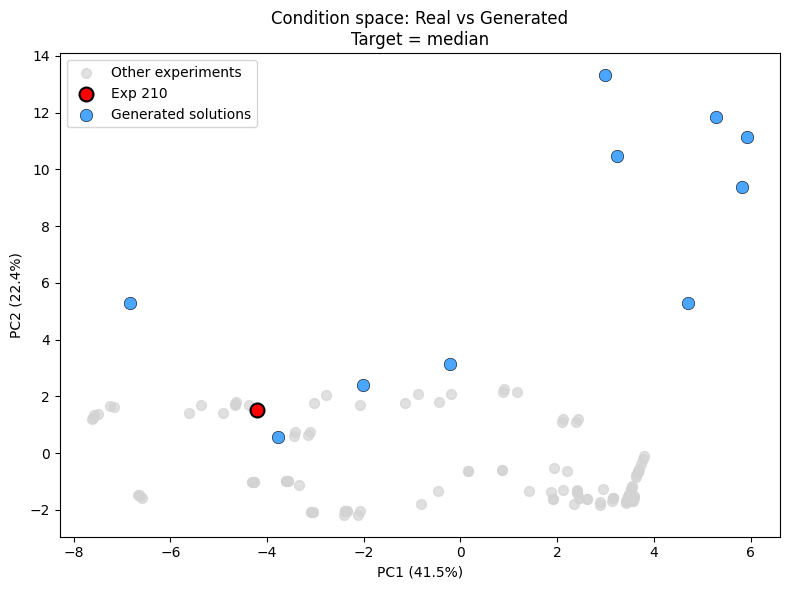

In [ ]:
# ----------------------------------------------------------------------
# Prepare unique real condition vectors (one per experiment)
# ----------------------------------------------------------------------
# Real condition vectors (assumed shape (n_cells, n_protocol))
real_matrix = None
if real_matrix is None:
    real_conds = adata_phi.obsm["condition_concat"]   # or use obs[protocol_columns].values
    exp_nums = adata_phi.obs["experiment_number"].values

    # Get unique condition per experiment
    unique_exps = np.unique(exp_nums)
    real_matrix = []
    exp_labels = []
    for exp in unique_exps:
        mask = exp_nums == exp
        cond = real_conds[mask][0]   # all cells in same exp share the same condition
        real_matrix.append(cond)
        exp_labels.append(exp)
    real_matrix = np.array(real_matrix)   # (n_exp, n_protocol)
    exp_labels = np.array(exp_labels)


# ----------------------------------------------------------------------
# Plot for each optimization run (no density)
# ----------------------------------------------------------------------
# opt_samples shape: (N, n_protocol) – N optimized solutions
opt_samples = np.maximum(opt_samples, 0)
N_opt = opt_samples.shape[0]

# Combine real + this run's generated
combined = np.vstack([real_matrix, opt_samples])

# PCA
pca = PCA(n_components=2)
combined_pca = pca.fit_transform(combined)

n_real = real_matrix.shape[0]
real_pca = combined_pca[:n_real]
generated_pca = combined_pca[n_real:]

# Plot
plt.figure(figsize=(8, 6))

# Real experiments: highlight experiment 210
is_exp210 = (exp_labels == 210)
plt.scatter(real_pca[~is_exp210, 0], real_pca[~is_exp210, 1],
            c='lightgray', label='Other experiments', s=50, alpha=0.7)
plt.scatter(real_pca[is_exp210, 0], real_pca[is_exp210, 1],
            c='red', label='Exp 210', s=100, edgecolors='black', linewidth=1.5, zorder=5)

# Generated conditions (uniform colour, no density)
plt.scatter(generated_pca[:, 0], generated_pca[:, 1],
            c='dodgerblue', s=80, label='Generated solutions',
            edgecolors='black', linewidth=0.5, alpha=0.8)

# Labels and title
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'Condition space: Real vs Generated\nTarget = {target_type}')
plt.legend()
plt.tight_layout()
plt.show()